In [1]:
#1. Load the df from csv file
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

PALETTE = ['#2a78d6', '#1baf7a', '#eda100', '#e34948',
           '#4a3aa7', '#eb6834', '#e87ba4', '#888']
ACCENT  = '#2a78d6'

df = pd.read_csv("dynamic_pricing.csv")
df_intial= pd.read_csv("dynamic_pricing.csv")

df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [ ]:
#2. Data Preparation/ Data Cleaning

def validate_numeric(df: pd.DataFrame, columns_map: dict) -> pd.DataFrame:

    """Filters a DataFrame to keep rows with numeric data type depending on column

    Args:
        df: The input pandas DataFrame.
        columns_map: A dict of numeric columns with correspnding int or float type

    Returns:
        A DataFrame containing only the valid rows.
    """

    for col, type in columns_map.items():
        if col in df.columns:
            #Convert numeric data, non-numeric will be 'NaN'
            df[col] = pd.to_numeric(df[col], errors = "coerce")

            #Drop 'nan'
            df= df.dropna(subset = [col])

            #Check int or float data types, drop wrong data type
            if type == "int":
                df = df[df[col] % 1 == 0]
                df[col] = df[col].astype(int)

            elif type == 'float':
                df[col] = df[col].astype(float)

    return df

def validate_string(df: pd.DataFrame, col: str, allowed_str: list) -> pd.DataFrame:

    """Filters a DataFrame to keep rows with allowed string categories from list

    Args:
        df: The input pandas DataFrame.
        col: The column name to validate.
        allowed_str: A list of acceptable string values.

    Returns:
        A DataFrame containing only the valid rows.
    """
    
    if col in df.columns:
        #Format strings by removing possible invisible spaces
        df[col] = df[col].astype(str).str.strip()
        
        # Keep only rows where the value exists in our allowed list
        df = df[df[col].isin(allowed_str)]
    
    return df


def remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:    
    """
    Count how many duplicate rows exist across all columns,
    'duplicated()' returns a series of values that describe
    which rows in the DataFrame are duplicated and not

    Args:
        df: The input pandas DataFrame.

    Returns:
        A DataFrame containing only the valid rows.
    """
    
    duplicate_count = df.duplicated().sum()
    
    if duplicate_count > 0:
        #keep='first' keeps the first occurrence and drops the duplicates, and reset_index for correcting index 
        df = df.drop_duplicates(keep='first').reset_index(drop=True)
    else:
        pass
        
    return df

    

# Define the schema rules for the dataset columns
numeric_rules = {
    'Number_of_Riders': 'int',
    'Number_of_Drivers': 'int',
    'Number_of_Past_Rides': 'int',
    'Average_Ratings': 'float',
    'Expected_Ride_Duration': 'int',
    'Historical_Cost_of_Ride': 'float'
}

#Define the categories
loc_category = ['Urban', 'Suburban', 'Rural']
stat_category = ['Silver', 'Regular', 'Gold']
time_category = ['Morning', 'Afternoon', 'Evening', 'Night']
vehicle_category = ['Economy', 'Premium']

# Run the functions 
df = remove_duplicates(df)
df = validate_numeric(df, numeric_rules)
df = validate_string(df, 'Location_Category', loc_category)
df = validate_string(df, 'Customer_Loyalty_Status', stat_category)
df = validate_string(df, 'Time_of_Booking', time_category)
df = validate_string(df, 'Vehicle_Type', vehicle_category)

df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [4]:
df_intial.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [9]:
#leaning Report — using results from the cleaning functions above

# Missing values (df is already cleaned by validate_numeric / validate_string)
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
cleaning_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing value report\n" + "-"*35)
print(cleaning_report)
print(f"\n\t✅  No missing values detected — dataset is complete.")

# Duplicates (remove_duplicates already ran above — just report the result)
dupes = df.duplicated().sum()
print(f"\nDuplicate rows : {dupes}")
if dupes:
    print(f"\t⚠️  {dupes} duplicates still found.")
else:
    print("\t✅  No duplicate rows.")


Missing value report
-----------------------------------
                         Missing Count  Missing %
Number_of_Riders                     0        0.0
Number_of_Drivers                    0        0.0
Location_Category                    0        0.0
Customer_Loyalty_Status              0        0.0
Number_of_Past_Rides                 0        0.0
Average_Ratings                      0        0.0
Time_of_Booking                      0        0.0
Vehicle_Type                         0        0.0
Expected_Ride_Duration               0        0.0
Historical_Cost_of_Ride              0        0.0

	✅  No missing values detected — dataset is complete.

Duplicate rows : 0
	✅  No duplicate rows.


In [10]:
# Preparing data for Problem 1

# Prevent division by zero errors
df = df[df['Number_of_Drivers'] > 0]
df = df[df['Number_of_Riders'] > 0]

# Calculate the Supply Demand Ratio
df['Supply_Demand_Ratio'] = df['Number_of_Drivers'] / df['Number_of_Riders']
df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Supply_Demand_Ratio
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,0.500000
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,0.672414
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,0.738095
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,0.314607
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,0.282051


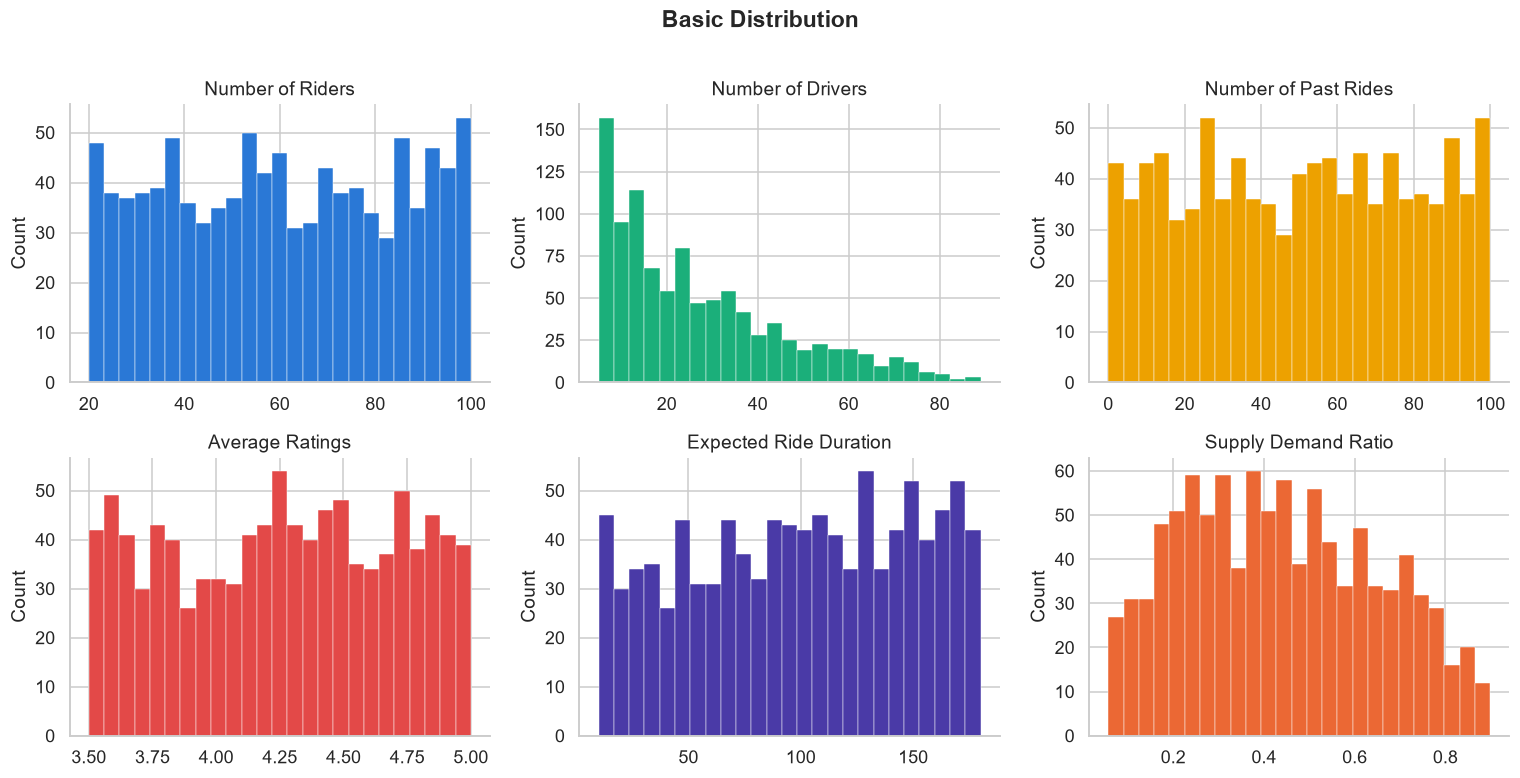

In [11]:
#Baisc distribution for pre-analysis
num_cols = ['Number_of_Riders', 'Number_of_Drivers', 'Number_of_Past_Rides',
            'Average_Ratings', 'Expected_Ride_Duration', 'Supply_Demand_Ratio']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, color=PALETTE[i], edgecolor='white', linewidth=0.3)
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.suptitle('Basic Distribution', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


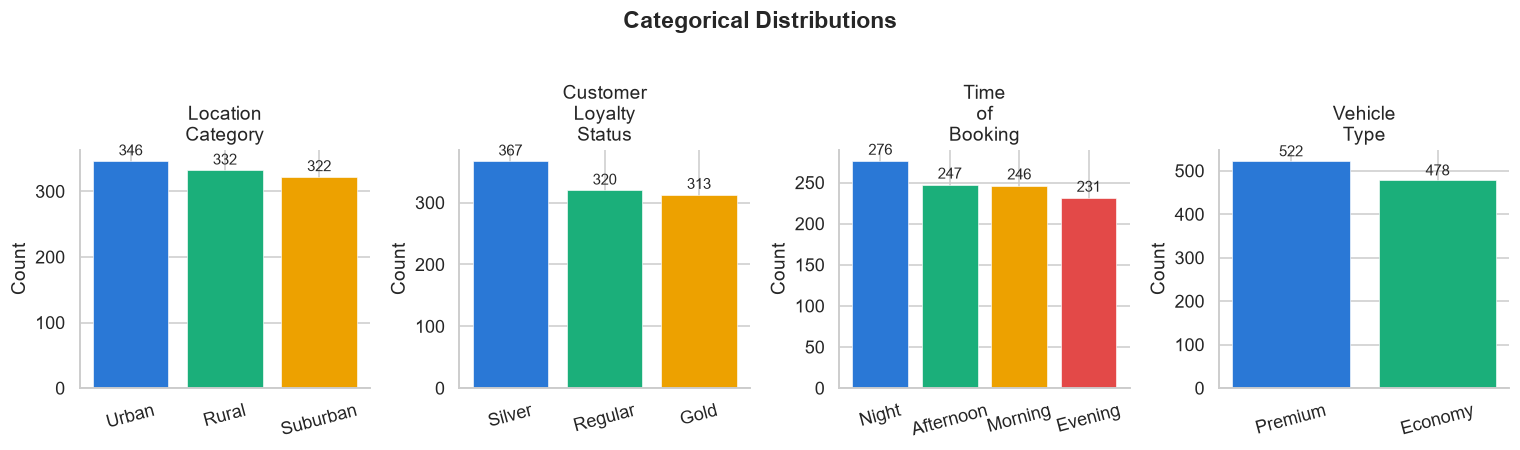

In [ ]:
# Basic distribution (category) for pre-analysis #2
cat_cols = ['Location_Category', 'Customer_Loyalty_Status',
            'Time_of_Booking', 'Vehicle_Type']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    bars = ax.bar(vc.index, vc.values,
                  color=PALETTE[:len(vc)], edgecolor='white', linewidth=0.4)
    ax.set_title(col.replace('_', '\n'))
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                str(val), ha='center', va='bottom', fontsize=10)

plt.suptitle('Categorical Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
